<a href="https://colab.research.google.com/github/Optimus0205/Data_Science_Project/blob/main/Missing_Value_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
df=pd.read_csv('/content/gurgaon_properties_outlier_treated.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area/room
0,flat,eldeco accolade,sohna road,0.87,5963.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,10.0,NaN,Relatively New,1457.0,NaN,849.00,1,0,0,0,0,0,72,729.500000
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,0.0,South-East,Relatively New,2087.0,NaN,NaN,0,0,0,0,0,0,157,521.750000
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,10.0,NaN,Moderately Old,2086.0,NaN,NaN,0,1,0,0,0,1,120,695.333333
3,flat,emaar palm gardens,sector 83,1.75,9211.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,6.0,East,Relatively New,1900.0,1600.0,1240.04,0,1,0,0,0,1,174,633.333333
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,2.0,East,Relatively New,1134.0,NaN,NaN,1,0,0,0,0,0,110,563.500000


In [4]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [5]:
df.shape

(3268, 24)

## Features to work:
*   floorNum
*   facing
*   agePossession
*   super_built_up_area
*   built_up_area
*   carpet_area

### 1. built_up_area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

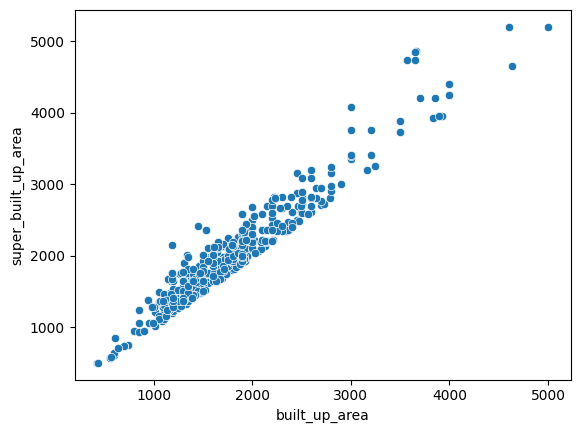

In [7]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

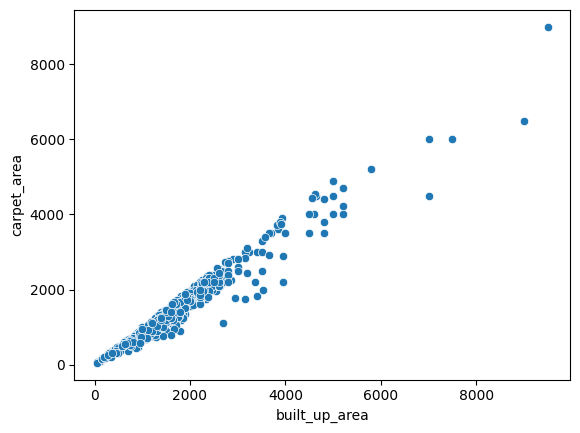

In [9]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [11]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

,0
0,False
1,False
2,False
3,False
4,False
...,...
3263,False
3264,False
3265,False
3266,False


In [12]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [13]:
all_present_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area/room
3,flat,emaar palm gardens,sector 83,1.75,9211.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,6.0,East,Relatively New,1900.0,1600.00,1240.04,0,1,0,0,0,1,174,633.333333
12,flat,emaar mgf the palm drive,sector 66,3.45,15682.0,2200.0,Super Built up area 2200(204.39 sq.m.)Built Up...,3,4,3,6.0,East,Relatively New,2200.0,2000.00,1800.00,0,1,0,0,0,1,95,733.333333
14,flat,experion the heartsong,sector 108,1.70,8487.0,2003.0,Super Built up area 2003(186.08 sq.m.)Built Up...,3,4,3+,14.0,South-East,Relatively New,2003.0,1500.29,1140.98,0,1,0,0,0,0,119,667.666667
15,flat,tulip purple,sector 69,1.80,9000.0,2000.0,Super Built up area 2400(222.97 sq.m.)Built Up...,4,5,3+,4.0,North-East,Relatively New,2400.0,2200.00,2000.00,0,1,0,0,0,0,165,500.000000
16,flat,dlf regal gardens,sector 90,1.27,5498.0,2310.0,Super Built up area 1755(163.04 sq.m.)Built Up...,3,3,3+,2.0,South-West,Relatively New,1755.0,1500.00,1400.00,0,0,0,0,1,0,72,770.000000


In [14]:
all_present_df.shape

(516, 24)

In [15]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [16]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [17]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.104164619164619 0.9009597281535565


In [18]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [19]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area/room
0,flat,eldeco accolade,sohna road,0.87,5963.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,10.0,NaN,Relatively New,1457.0,NaN,849.0,1,0,0,0,0,0,72,729.500000
8,flat,emaar mgf emerald floors premier,sector 65,2.55,15455.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,3.0,West,Relatively New,1650.0,NaN,1300.0,1,1,0,0,0,0,21,550.000000
9,flat,ramson kshitij sec-95 gurugram,sector 95,0.27,2700.0,1000.0,Super Built up area 1000(92.9 sq.m.)Carpet are...,2,2,0,1.0,West,Undefined,1000.0,NaN,550.0,0,0,0,0,0,0,0,500.000000
22,flat,ireo the corridors,sector 67a,1.62,9380.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,4.0,North,New Property,1727.0,NaN,1017.0,0,0,1,0,0,1,142,575.666667
35,flat,ireo the corridors,sector 67a,1.70,9844.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,10.0,North-East,New Property,1727.0,NaN,1017.0,0,1,0,0,1,1,44,575.666667


In [20]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

/tmp/ipykernel_9455/1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
/tmp/ipykernel_9455/1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'].fillna(round(((sbc_df['super_bu

In [21]:
df.update(sbc_df)

In [22]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [23]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [24]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area/room
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,0.0,South-East,Relatively New,2087.0,NaN,NaN,0,0,0,0,0,0,157,521.750000
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,10.0,NaN,Moderately Old,2086.0,NaN,NaN,0,1,0,0,0,1,120,695.333333
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,2.0,East,Relatively New,1134.0,NaN,NaN,1,0,0,0,0,0,110,563.500000
11,flat,shree vardhman flora,sector 90,0.65,4815.0,1350.0,Super Built up area 1350(125.42 sq.m.),2,2,3,6.0,West,Relatively New,1350.0,NaN,NaN,1,0,0,0,0,0,174,675.000000
13,flat,ss the leaf,sector 85,1.14,6433.0,1772.0,Super Built up area 1772(164.62 sq.m.),2,2,3,16.0,South,Relatively New,1772.0,NaN,NaN,0,0,0,0,0,0,44,886.000000


In [25]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

/tmp/ipykernel_9455/1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
/tmp/ipykernel_9455/1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


In [26]:
df.update(sb_df)

In [27]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [28]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [29]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area/room
6,flat,godrej nature plus,sector 33,1.65,14335.0,1151.0,Carpet area: 1151 (106.93 sq.m.),2,2,3,1.0,East,Under Construction,NaN,NaN,1151.000000,0,0,0,0,0,0,38,575.500000
7,flat,rof ananda,sector 95,0.38,5901.0,644.0,Carpet area: 644.12 (59.84 sq.m.),3,2,1,2.0,South-East,Relatively New,NaN,NaN,644.111776,0,0,0,1,0,1,66,214.666667
25,flat,sare homes,sector 92,0.65,4587.0,1417.0,Carpet area: 1417 (131.64 sq.m.),3,3,2,3.0,NaN,Relatively New,NaN,NaN,1417.000000,0,0,0,0,0,0,6,472.333333
28,flat,ramsons kshitij,sector 95,0.40,5839.0,685.0,Carpet area: 685 (63.64 sq.m.),3,2,2,6.0,NaN,Undefined,NaN,NaN,685.000000,0,0,0,0,0,0,0,228.333333
29,flat,signature global solera,sector 107,0.52,8062.0,645.0,Carpet area: 645 (59.92 sq.m.),3,2,2,5.0,East,Relatively New,NaN,NaN,645.000000,0,0,0,0,1,0,15,215.000000


In [30]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

/tmp/ipykernel_9455/2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
/tmp/ipykernel_9455/2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)


In [31]:
df.update(c_df)

In [32]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


<Axes: xlabel='built_up_area', ylabel='price'>

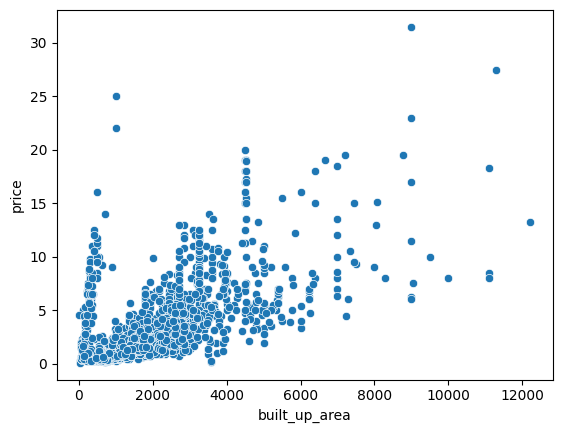

In [34]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [35]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [36]:
anamoly_df.sample(5)

,price,area,built_up_area
2514,3.50,1458.0,161.0
1890,2.60,1711.0,1548.0
1385,3.29,1828.0,1654.0
3211,6.50,3240.0,360.0
1348,2.80,2047.0,1971.0


In [37]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [38]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

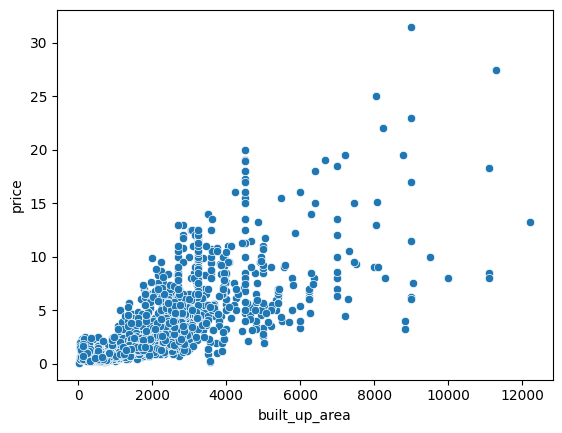

In [40]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [42]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area/room'],inplace=True)

In [43]:
df.shape

(3268, 19)

In [44]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5963.0,2,2,3+,10.0,NaN,Relatively New,1131.0,1,0,0,0,0,0,72
1,flat,tulip violet,sector 69,2.00,9583.0,4,4,2,0.0,South-East,Relatively New,1889.0,0,0,0,0,0,0,157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,3,3,3+,10.0,NaN,Moderately Old,1888.0,0,1,0,0,0,1,120
3,flat,emaar palm gardens,sector 83,1.75,9211.0,3,3,3,6.0,East,Relatively New,1600.0,0,1,0,0,0,1,174
4,flat,vatika iris floors,sector 82,0.63,5590.0,2,2,3+,2.0,East,Relatively New,1026.0,1,0,0,0,0,0,110


In [45]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,16
facing,831


Features to work:
*   floorNum
*   facing
*   agePossession
*   super_built_up_area (Done)
*   built_up_area       (Done)
*   carpet_area         (Done)

### 2. floorNum

In [46]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1064,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,0,0
1094,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,0,0
1128,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,0,21
1255,house,independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,540.0,0,0,0,0,0,0,9
1542,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,0,0
1919,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,0,0
1938,house,independent,sector 4,4.12,8889.0,2,1,3+,NaN,NaN,Moderately Old,4635.0,0,0,0,0,0,0,0
2116,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0
2173,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,1,114
2194,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,0,59


In [47]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [48]:
df['floorNum'].fillna(2.0,inplace=True)

/tmp/ipykernel_9455/15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [49]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
facing,831


### 3. facing

In [50]:
831/df.shape[0]

0.25428396572827416

25% value has to be imputed

<Axes: ylabel='count'>

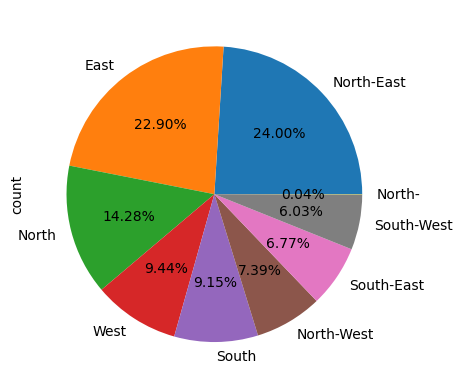

In [51]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [52]:
df.drop(columns=['facing'],inplace=True)

In [53]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2813,flat,corona optus,sector 37c,1.27,7204.0,3,3,3,2.0,Relatively New,1581.0,1,0,0,0,1,0,49
2258,flat,eldeco accolade,sohna road,0.72,4976.0,2,2,3+,12.0,Relatively New,1131.0,1,0,0,0,0,0,152
1624,flat,imperia the esfera,sector 37c,1.10,5405.0,3,4,3,9.0,Relatively New,1899.0,1,1,0,0,0,0,49
2057,flat,ireo the corridors,sector 67a,1.50,11111.0,2,2,2,10.0,Relatively New,1500.0,0,0,1,0,0,1,38
2749,flat,the cocoon,dwarka expressway,2.00,13333.0,3,3,3,5.0,New Property,1357.0,0,0,0,0,0,0,0


In [54]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


### 4. agePossession
undefined is very large 385

In [55]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1537
Moderately Old,517
New Property,475
Undefined,385
Old Property,274
Under Construction,80


In [56]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
9,flat,ramson kshitij sec-95 gurugram,sector 95,0.27,2700.0,2,2,0,1.0,Undefined,758.0,0,0,0,0,0,0,0
28,flat,ramsons kshitij,sector 95,0.40,5839.0,3,2,2,6.0,Undefined,761.0,0,0,0,0,0,0,0
32,flat,imperia elvedor,sector 37c,0.55,8221.0,1,1,0,5.0,Undefined,669.0,0,0,0,0,0,0,0
44,flat,sare petioles,sector 92,1.30,6373.0,4,4,0,7.0,Undefined,2040.0,0,0,0,0,0,0,0
47,flat,greenopolis,sector 89,0.65,5196.0,2,2,2,15.0,Undefined,1390.0,0,0,0,0,0,0,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3193,flat,godrej nature plus serenity,sector 33,1.39,11583.0,3,2,3+,23.0,Undefined,1333.0,0,0,0,0,0,0,105
3202,flat,signature global city 81,sector 81,0.82,8641.0,2,2,3,2.0,Undefined,955.0,0,0,0,0,0,0,53
3208,house,dlf the grove,sector 54,5.70,23457.0,4,4,0,1.0,Undefined,2430.0,0,0,0,0,0,0,46
3211,house,vatika india next,sector 82,6.50,20062.0,4,3,0,2.0,Undefined,3240.0,0,0,0,0,0,0,0


In [57]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [58]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [59]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1709
Moderately Old,557
New Property,537
Old Property,303
Undefined,82
Under Construction,80


In [60]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [61]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [62]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1721
Moderately Old,560
New Property,539
Old Property,306
Under Construction,80
Undefined,62


In [63]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [64]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [65]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1747
Moderately Old,596
New Property,539
Old Property,306
Under Construction,80


In [66]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [67]:
df.shape

(3268, 18)

In [68]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)